---
title: "Autocorre"
author: "Harlow Malloc"
date: "2026-05-05"
categories: [ code, analysis,autocorrelation]
image: "OIP-574833120.jpg"
---

In [38]:
import requests
url = "https://servicios.ine.es/wstempus/js/ES/DATOS_SERIE/IPC206449?nult=200"

In [39]:
respuesta = requests.get(url)
print(respuesta.status_code)
print(respuesta.json())

200
{'COD': 'IPC206449', 'Nombre': 'Nacional. Índice general. Variación mensual. ', 'FK_Unidad': 135, 'FK_Escala': 1, 'Data': [{'Fecha': 1114898400000, 'FK_TipoDato': 1, 'FK_Periodo': 5, 'Anyo': 2005, 'Valor': 0.2, 'Secreto': False}, {'Fecha': 1117576800000, 'FK_TipoDato': 1, 'FK_Periodo': 6, 'Anyo': 2005, 'Valor': 0.2, 'Secreto': False}, {'Fecha': 1120168800000, 'FK_TipoDato': 1, 'FK_Periodo': 7, 'Anyo': 2005, 'Valor': -0.6, 'Secreto': False}, {'Fecha': 1122847200000, 'FK_TipoDato': 1, 'FK_Periodo': 8, 'Anyo': 2005, 'Valor': 0.4, 'Secreto': False}, {'Fecha': 1125525600000, 'FK_TipoDato': 1, 'FK_Periodo': 9, 'Anyo': 2005, 'Valor': 0.6, 'Secreto': False}, {'Fecha': 1128117600000, 'FK_TipoDato': 1, 'FK_Periodo': 10, 'Anyo': 2005, 'Valor': 0.8, 'Secreto': False}, {'Fecha': 1130799600000, 'FK_TipoDato': 1, 'FK_Periodo': 11, 'Anyo': 2005, 'Valor': 0.2, 'Secreto': False}, {'Fecha': 1133391600000, 'FK_TipoDato': 1, 'FK_Periodo': 12, 'Anyo': 2005, 'Valor': 0.2, 'Secreto': False}, {'Fecha': 113

In [41]:
datos_json = respuesta.json()
print(type(datos_json))

<class 'dict'>


In [48]:
print(datos_json.keys())

dict_keys(['COD', 'Nombre', 'FK_Unidad', 'FK_Escala', 'Data'])


In [51]:
print(datos_json['Data'][0])
print(datos_json['Data'][1])

{'Fecha': 1114898400000, 'FK_TipoDato': 1, 'FK_Periodo': 5, 'Anyo': 2005, 'Valor': 0.2, 'Secreto': False}
{'Fecha': 1117576800000, 'FK_TipoDato': 1, 'FK_Periodo': 6, 'Anyo': 2005, 'Valor': 0.2, 'Secreto': False}


In [56]:
Electricidad = pd.DataFrame.from_dict(datos_json['Data'])

In [57]:
print(Electricidad.head())
print(Electricidad.shape)

           Fecha  FK_TipoDato  FK_Periodo  Anyo  Valor  Secreto Notas
0  1114898400000            1           5  2005    0.2    False   NaN
1  1117576800000            1           6  2005    0.2    False   NaN
2  1120168800000            1           7  2005   -0.6    False   NaN
3  1122847200000            1           8  2005    0.4    False   NaN
4  1125525600000            1           9  2005    0.6    False   NaN
(200, 7)


In [58]:
Electricidad.columns = ["fecha","fk_dt","fk_period","ano","valor","secreto","notas"]

In [61]:
df_elec = Electricidad[["ano","fk_period", "valor"]]

In [62]:
df_elec.head()

,ano,fk_period,valor
0,2005,5,0.2
1,2005,6,0.2
2,2005,7,-0.6
3,2005,8,0.4
4,2005,9,0.6


# Temperature data

In [63]:
url_temp = "https://servicios.ine.es/wstempus/js/ES/DATOS_SERIE/IPC206450?nult=200"
respuesta_temp = requests.get(url_temp)
print(respuesta_temp.status_code)

200


In [67]:
temp_dict = respuesta_temp.json()

In [70]:
temp_df = pd.DataFrame.from_dict(temp_dict['Data'])

In [75]:
temp_df = temp_df[["Anyo","FK_Periodo","Valor"]]

In [77]:
temp_df.columns=["ano","fk_period","valor"]

In [89]:
df= df_elec.merge(temp_df, left_on = ["ano","fk_period"],right_on = ["ano", "fk_period"])

In [91]:
df.columns = ["ano", "fk_period", "electricidad", "temperatura"]

In [93]:
df

,ano,fk_period,electricidad,temperatura
0,2005,5,0.2,2.7
1,2005,6,0.2,2.9
2,2005,7,-0.6,2.7
3,2005,8,0.4,2.7
4,2005,9,0.6,2.9
...,...,...,...,...
195,2021,8,0.5,0.7
196,2021,9,0.8,0.7
197,2021,10,1.8,0.9
198,2021,11,0.3,1.4


In [94]:
import seaborn as sns

In [98]:
df

,ano,fk_period,electricidad,temperatura
0,2005,5,0.2,2.7
1,2005,6,0.2,2.9
2,2005,7,-0.6,2.7
3,2005,8,0.4,2.7
4,2005,9,0.6,2.9
...,...,...,...,...
195,2021,8,0.5,0.7
196,2021,9,0.8,0.7
197,2021,10,1.8,0.9
198,2021,11,0.3,1.4


In [104]:
df

,ano,fk_period,electricidad,temperatura,fecha
0,2005,5,0.2,2.7,2005-05-01
1,2005,6,0.2,2.9,2005-06-01
2,2005,7,-0.6,2.7,2005-07-01
3,2005,8,0.4,2.7,2005-08-01
4,2005,9,0.6,2.9,2005-09-01
...,...,...,...,...,...
195,2021,8,0.5,0.7,2021-08-01
196,2021,9,0.8,0.7,2021-09-01
197,2021,10,1.8,0.9,2021-10-01
198,2021,11,0.3,1.4,2021-11-01


<Axes: xlabel='fecha', ylabel='electricidad'>

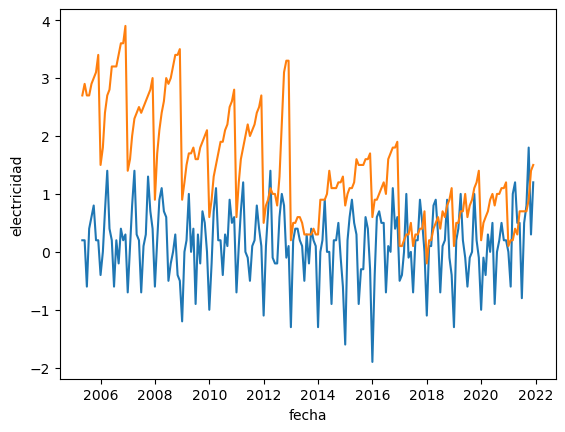

In [109]:
sns.lineplot(data = df,x = 'fecha', y = 'electricidad')
sns.lineplot(data = df,x = 'fecha', y = 'temperatura')

In [111]:
import numpy as np
import statsmodels.api as sm

,GPA,TUCE,PSI,GRADE
0,2.66,20.0,0.0,0.0
1,2.89,22.0,0.0,0.0
2,3.28,24.0,0.0,0.0
3,2.92,12.0,0.0,0.0
4,4.00,21.0,0.0,1.0
5,2.86,17.0,0.0,0.0
6,2.76,17.0,0.0,0.0
7,2.87,21.0,0.0,0.0
8,3.03,25.0,0.0,0.0
9,3.92,29.0,0.0,1.0
